In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
from pathlib import Path

cwd = Path.cwd()
print(cwd)

/Users/govils/Desktop/Duke/AIPI 510/Project 1 - NFL Injury Analysis/Rahul Analysis


In [8]:
script_dir = cwd.resolve().parent
data_folder_path = script_dir / "Data"

injuries = pd.read_csv(data_folder_path / "injuries_preprocessed.csv")
injuries_spells = pd.read_csv(data_folder_path / "injuries_spells.csv")
schedules = pd.read_csv(data_folder_path / "schedules.csv")
players = pd.read_csv(data_folder_path / "players.csv")
snap_counts = pd.read_csv(data_folder_path / "snap_counts.csv")

In [6]:
injuries.head()

,season,game_type,team,week,gsis_id,position,full_name,first_name,last_name,report_primary_injury,...,practice_primary_injury,practice_secondary_injury,practice_status,date_modified,season_type,clean_injury,prev_week,prev_injury,is_new_spell,spell_id
0,2009.0,REG,DAL,4.0,00-0000045,T,Flozell Adams,Flozell,Adams,Shoulder,...,Shoulder,NaN,Full Participation in Practice,NaN,NaN,Shoulder,NaN,NaN,True,1
1,2009.0,REG,DAL,5.0,00-0000045,T,Flozell Adams,Flozell,Adams,Shoulder,...,Shoulder,NaN,Full Participation in Practice,NaN,NaN,Shoulder,4.0,Shoulder,False,1
2,2010.0,REG,PIT,8.0,00-0000045,T,Flozell Adams,Flozell,Adams,Ankle,...,Ankle,NaN,Full Participation in Practice,2010-10-29 10:41:44+00:00,NaN,Ankle,NaN,NaN,True,1
3,2010.0,REG,PIT,13.0,00-0000045,T,Flozell Adams,Flozell,Adams,Back,...,Back,NaN,Full Participation in Practice,2010-12-03 10:36:33+00:00,NaN,Back,8.0,Ankle,True,2
4,2010.0,REG,PIT,14.0,00-0000045,T,Flozell Adams,Flozell,Adams,Ankle,...,Ankle,NaN,Full Participation in Practice,2010-12-10 10:19:54+00:00,NaN,Ankle,13.0,Back,True,3


In [7]:
injuries_spells.head()

,gsis_id,full_name,season,spell_id,clean_injury,injury_onset_week,weeks_on_report
0,00-0000045,Flozell Adams,2009.0,1,Shoulder,4.0,2
1,00-0000045,Flozell Adams,2010.0,1,Ankle,8.0,1
2,00-0000045,Flozell Adams,2010.0,2,Back,13.0,1
3,00-0000045,Flozell Adams,2010.0,3,Ankle,14.0,2
4,00-0000108,David Akers,2010.0,1,Unspecified,13.0,1


### Are injuries more prevalent in colder weather? Does the type of playing surface amplify this?

In [9]:
injuries_spells['team'] = pd.merge(
    injuries_spells, injuries[['gsis_id', 'season', 'team']], on=['gsis_id', 'season'], how='left'
)['team']

injuries_spells.head()

,gsis_id,full_name,season,spell_id,clean_injury,injury_onset_week,weeks_on_report,team
0,00-0000045,Flozell Adams,2009.0,1,Shoulder,4.0,2,DAL
1,00-0000045,Flozell Adams,2010.0,1,Ankle,8.0,1,DAL
2,00-0000045,Flozell Adams,2010.0,2,Back,13.0,1,PIT
3,00-0000045,Flozell Adams,2010.0,3,Ankle,14.0,2,PIT
4,00-0000108,David Akers,2010.0,1,Unspecified,13.0,1,PIT


In [12]:
home_df = schedules[
    ["season", "week", "home_team", "home_rest", "roof", "surface", "temp", "wind"]
].rename(columns={"home_team": "team", "home_rest": "rest"})

away_df = schedules[
    ["season", "week", "away_team", "away_rest", "roof", "surface", "temp", "wind"]
].rename(columns={"away_team": "team", "away_rest": "rest"})

In [13]:
team_schedules = pd.concat([home_df, away_df], ignore_index=True)

In [ ]:
# generate merged dataframe pulling in relevant schedule information for each injury spell

injuries_spells_with_schedule_info = injuries_spells.merge(
    team_schedules,
    left_on=["season", "injury_onset_week", "team"],
    right_on=["season", "week", "team"],
    how="left",
).drop(columns=["week"])

injuries_spells_with_schedule_info.head()

,gsis_id,full_name,season,spell_id,clean_injury,injury_onset_week,weeks_on_report,team,rest,roof,surface,temp,wind
0,00-0000045,Flozell Adams,2009.0,1,Shoulder,4.0,2,DAL,6.0,outdoors,grass,55.0,6.0
1,00-0000045,Flozell Adams,2010.0,1,Ankle,8.0,1,DAL,6.0,closed,matrixturf,NaN,NaN
2,00-0000045,Flozell Adams,2010.0,2,Back,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0
3,00-0000045,Flozell Adams,2010.0,3,Ankle,14.0,2,PIT,7.0,outdoors,grass,37.0,8.0
4,00-0000108,David Akers,2010.0,1,Unspecified,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0


In [16]:
injuries_spells_with_schedule_info['freezing'] = injuries_spells_with_schedule_info['temp'].apply(
    lambda x: 1 if x <= 32 else 0
)

injuries_spells_with_schedule_info.head(20)

,gsis_id,full_name,season,spell_id,clean_injury,injury_onset_week,weeks_on_report,team,rest,roof,surface,temp,wind,freezing
0,00-0000045,Flozell Adams,2009.0,1,Shoulder,4.0,2,DAL,6.0,outdoors,grass,55.0,6.0,0
1,00-0000045,Flozell Adams,2010.0,1,Ankle,8.0,1,DAL,6.0,closed,matrixturf,NaN,NaN,0
2,00-0000045,Flozell Adams,2010.0,2,Back,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0,0
3,00-0000045,Flozell Adams,2010.0,3,Ankle,14.0,2,PIT,7.0,outdoors,grass,37.0,8.0,0
4,00-0000108,David Akers,2010.0,1,Unspecified,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0,0
5,00-0000108,David Akers,2012.0,1,Illness,7.0,1,PIT,10.0,outdoors,fieldturf,55.0,1.0,0
6,00-0000108,David Akers,2012.0,2,Pelvis,13.0,4,PIT,7.0,outdoors,sportturf,57.0,9.0,0
7,00-0000551,Brendon Ayanbadejo,2009.0,1,Foot,1.0,1,PIT,7.0,outdoors,dessograss,67.0,9.0,0
8,00-0000551,Brendon Ayanbadejo,2010.0,1,Knee,16.0,1,PIT,4.0,outdoors,grass,27.0,11.0,1
9,00-0000551,Brendon Ayanbadejo,2011.0,1,Head,10.0,1,PIT,7.0,outdoors,fieldturf,62.0,23.0,0


In [18]:
injuries_spells_with_schedule_info['freezing'].value_counts()

freezing
0    48594
1     1978
Name: count, dtype: int64

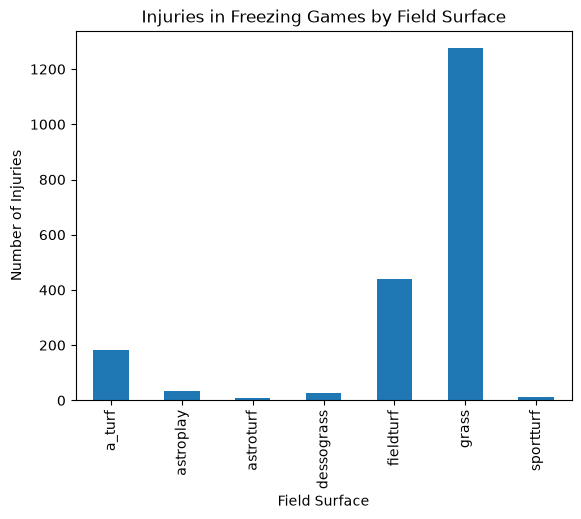

In [19]:
# for freezing games, are injuries more likely for specific types of field surface?
plt.figure()
injuries_spells_with_schedule_info[injuries_spells_with_schedule_info['freezing'] == 1].groupby('surface').size().plot(kind='bar')
plt.title('Injuries in Freezing Games by Field Surface')
plt.xlabel('Field Surface')
plt.ylabel('Number of Injuries')
plt.show()

Roughly half of stadiums (16/30) are grass, while the others are turf. A rough assumption is that half of games, then, would be on grass fields and the other half on turf fields. This makes the grass injuries relative to turf injuries staggering for freezing games.

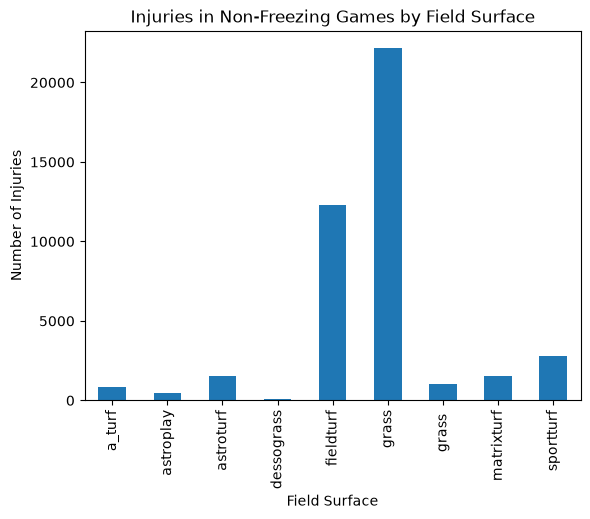

In [20]:
# How about for non-freezing games?
plt.figure()
injuries_spells_with_schedule_info[injuries_spells_with_schedule_info['freezing'] == 0].groupby('surface').size().plot(kind='bar')
plt.title('Injuries in Non-Freezing Games by Field Surface')
plt.xlabel('Field Surface')
plt.ylabel('Number of Injuries')
plt.show()

Grass still leads but it's notable that the gap is proportionally not as far. 

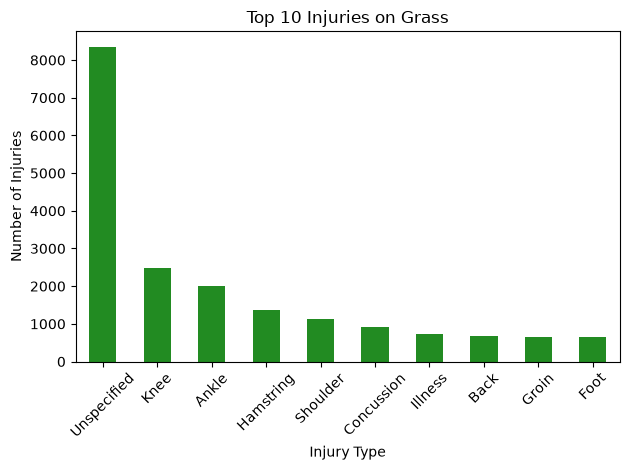

In [23]:
# What kinds of injuries are we seeing on grass? and turf?
plt.figure()
grass_top10 = (
    injuries_spells_with_schedule_info[
        injuries_spells_with_schedule_info["surface"] == "grass"
    ]["clean_injury"]
    .value_counts()
    .head(10)
)

grass_top10.plot(kind="bar", color="forestgreen")
plt.title("Top 10 Injuries on Grass")
plt.xlabel("Injury Type")
plt.ylabel("Number of Injuries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

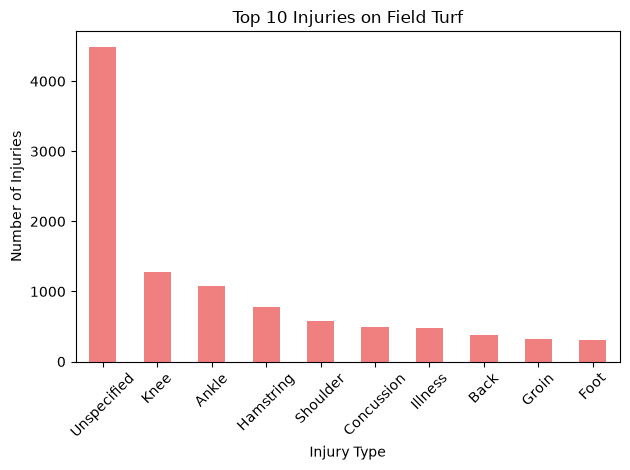

In [24]:
plt.figure()
turf_top10 = (
    injuries_spells_with_schedule_info[
        injuries_spells_with_schedule_info["surface"] == "fieldturf"
    ]["clean_injury"]
    .value_counts()
    .head(10)
)

turf_top10.plot(kind="bar", color="lightcoral")
plt.title("Top 10 Injuries on Field Turf")
plt.xlabel("Injury Type")
plt.ylabel("Number of Injuries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Data Limitation: we do not know if these are non-contact or contact injuries. Turf typically has more non-con injuries compared to grass, which cannot be shown here.

### Further field surface analysis

In [25]:
import numpy as np

In [31]:
df_env = injuries_spells_with_schedule_info.copy()

# Convert temperature to numeric, coercion replaces invalid entries with NaN
df_env["temp_numeric"] = pd.to_numeric(df_env["temp"], errors="coerce")

# (Domes and closed retractable roofs are climate-controlled around 70 degrees)
df_env["is_indoor"] = df_env['roof'] != 'outdoors'
df_env.loc[df_env["is_indoor"], "temp_numeric"] = 70.0

# Drop remaining rows where temperature or surface is missing
df_env = df_env.dropna(subset=["temp_numeric", "surface"])

# Create Temperature Buckets
temp_bins = [-np.inf, 40, 60, 80, np.inf]
temp_labels = ["Cold (<40°F)", "Mild (40-60°F)", "Warm (61-80°F) or Indoors", "Hot (>80°F)"]
df_env["temp_bucket"] = pd.cut(
    df_env["temp_numeric"], bins=temp_bins, labels=temp_labels
)

# Clean surface column (Ensure binary grass vs. turf)
df_env = df_env[df_env["surface"].isin(["grass", "fieldturf"])]

In [32]:
df_env.head()

,gsis_id,full_name,season,spell_id,clean_injury,injury_onset_week,weeks_on_report,team,rest,roof,surface,temp,wind,freezing,temp_numeric,is_indoor,temp_bucket
0,00-0000045,Flozell Adams,2009.0,1,Shoulder,4.0,2,DAL,6.0,outdoors,grass,55.0,6.0,0,55.0,False,Mild (40-60°F)
2,00-0000045,Flozell Adams,2010.0,2,Back,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0,0,35.0,False,Cold (<40°F)
3,00-0000045,Flozell Adams,2010.0,3,Ankle,14.0,2,PIT,7.0,outdoors,grass,37.0,8.0,0,37.0,False,Cold (<40°F)
4,00-0000108,David Akers,2010.0,1,Unspecified,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0,0,35.0,False,Cold (<40°F)
5,00-0000108,David Akers,2012.0,1,Illness,7.0,1,PIT,10.0,outdoors,fieldturf,55.0,1.0,0,55.0,False,Mild (40-60°F)


In [33]:
env_counts = (
    df_env.groupby(["temp_bucket", "surface"], observed=False)
    .size()
    .unstack(fill_value=0)
)

print("--- Total Injury Counts by Temperature and Surface ---")
print(env_counts)

--- Total Injury Counts by Temperature and Surface ---
surface                    fieldturf  grass
temp_bucket                                
Cold (<40°F)                    1513   3216
Mild (40-60°F)                  3118   6600
Warm (61-80°F) or Indoors       7641  10552
Hot (>80°F)                      222   2237


<Figure size 1000x600 with 0 Axes>

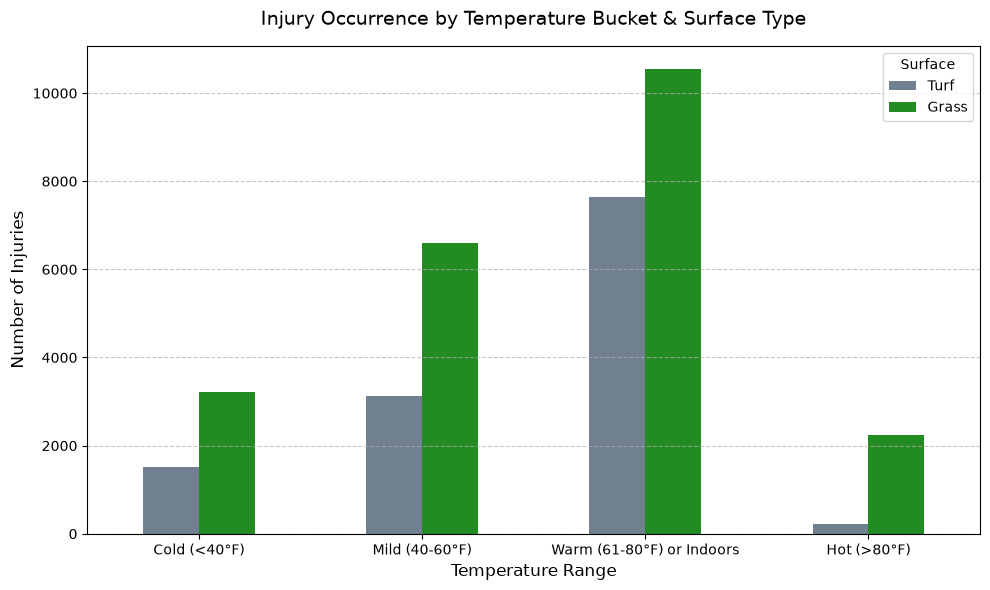

In [36]:
plt.figure(figsize=(10, 6))
env_counts.plot(kind="bar", figsize=(10, 6), color=["slategray", "forestgreen"])
plt.title(
    "Injury Occurrence by Temperature Bucket & Surface Type",
    fontsize=14,
    pad=15,
)
plt.xlabel("Temperature Range", fontsize=12)
plt.ylabel("Number of Injuries", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Surface", labels=["Turf", "Grass"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [43]:
soft_tissue_keywords = [
    "Hamstring",
    "Calf",
    "Groin",
    "Achilles",
    "Quadricep"
]

# Create a boolean mask for soft tissue injuries
df_env["is_soft_tissue"] = df_env["clean_injury"].isin(soft_tissue_keywords)

soft_tissue_counts = (
    df_env[df_env["is_soft_tissue"]]
    .groupby(["temp_bucket", "surface"], observed=False)
    .size()
    .unstack(fill_value=0)
)

In [44]:
soft_tissue_counts

surface,fieldturf,grass
temp_bucket,,
Cold (<40°F),139,313
Mild (40-60°F),374,709
Warm (61-80°F) or Indoors,988,1368
Hot (>80°F),31,312


<Figure size 1000x600 with 0 Axes>

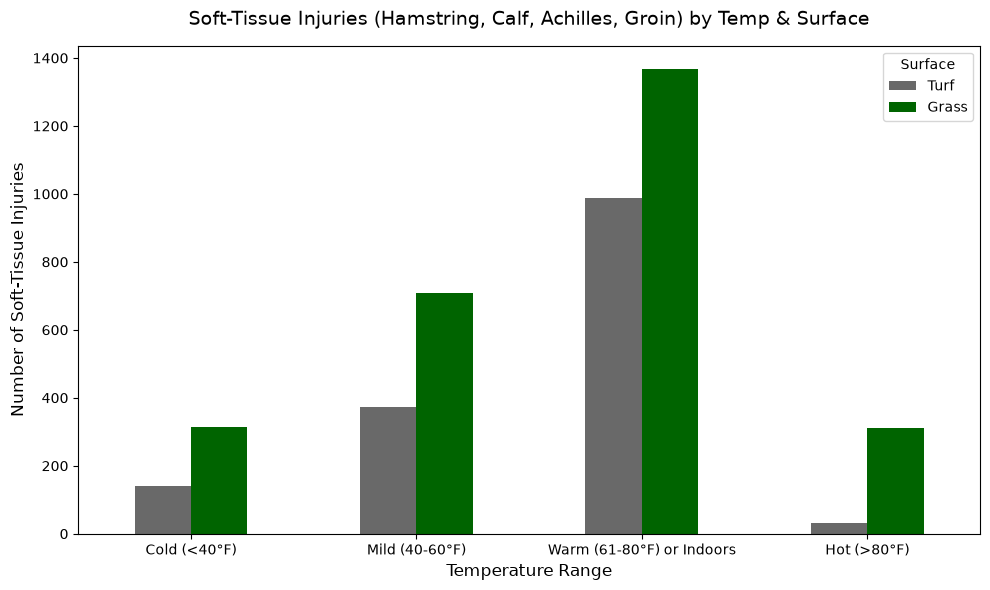

In [48]:
plt.figure(figsize=(10, 6))
soft_tissue_counts.plot(
    kind="bar", figsize=(10, 6), color=["dimgray", "darkgreen"]
)
plt.title(
    "Soft-Tissue Injuries (Hamstring, Calf, Achilles, Groin) by Temp & Surface",
    fontsize=14,
    pad=15,
)
plt.xlabel("Temperature Range", fontsize=12)
plt.ylabel("Number of Soft-Tissue Injuries", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Surface", labels=["Turf", "Grass"])
plt.tight_layout()
plt.show()

### How does rest affect injuries?

In [49]:
injuries_spells_with_schedule_info.head()

,gsis_id,full_name,season,spell_id,clean_injury,injury_onset_week,weeks_on_report,team,rest,roof,surface,temp,wind,freezing
0,00-0000045,Flozell Adams,2009.0,1,Shoulder,4.0,2,DAL,6.0,outdoors,grass,55.0,6.0,0
1,00-0000045,Flozell Adams,2010.0,1,Ankle,8.0,1,DAL,6.0,closed,matrixturf,NaN,NaN,0
2,00-0000045,Flozell Adams,2010.0,2,Back,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0,0
3,00-0000045,Flozell Adams,2010.0,3,Ankle,14.0,2,PIT,7.0,outdoors,grass,37.0,8.0,0
4,00-0000108,David Akers,2010.0,1,Unspecified,13.0,1,PIT,7.0,outdoors,fieldturf,35.0,17.0,0


In [53]:
injuries_spells_with_schedule_info['short_rest'] = injuries_spells_with_schedule_info['rest'] < 7.0
injuries_spells_with_schedule_info['short_rest'].value_counts()

short_rest
False    44341
True      6231
Name: count, dtype: int64

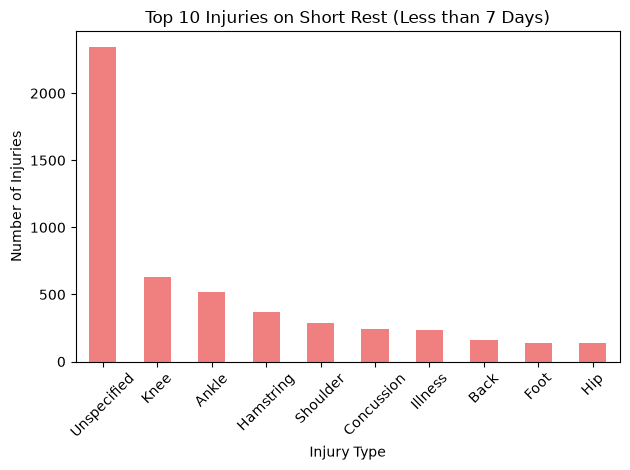

In [ ]:
plt.figure()
short_rest_top10 = (
    injuries_spells_with_schedule_info[
        injuries_spells_with_schedule_info["short_rest"] == True
    ]["clean_injury"]
    .value_counts()
    .head(10)
)

short_rest_top10.plot(kind="bar", color="lightcoral")
plt.title("Top 10 Injuries on Short Rest (Less than 7 Days)")
plt.xlabel("Injury Type")
plt.ylabel("Number of Injuries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

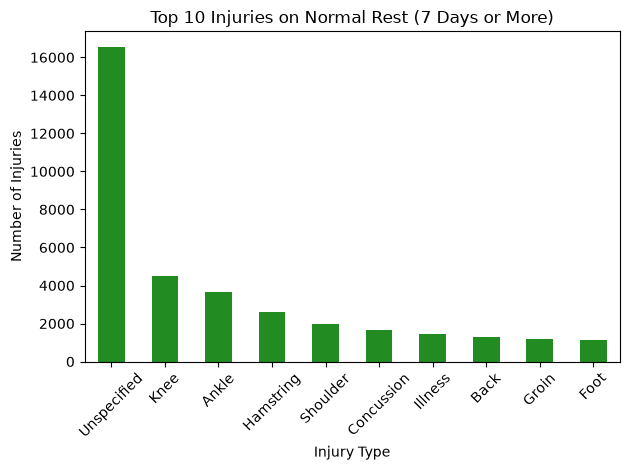

In [58]:
plt.figure()
normal_rest_top10 = (
    injuries_spells_with_schedule_info[
        injuries_spells_with_schedule_info["short_rest"] == False
    ]["clean_injury"]
    .value_counts()
    .head(10)
)

normal_rest_top10.plot(kind="bar", color="forestgreen")
plt.title("Top 10 Injuries on Normal Rest (7 Days or More)")
plt.xlabel("Injury Type")
plt.ylabel("Number of Injuries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Are injuries worse at different points in the season? Have some injuries gotten more/less prevalent in recent years?

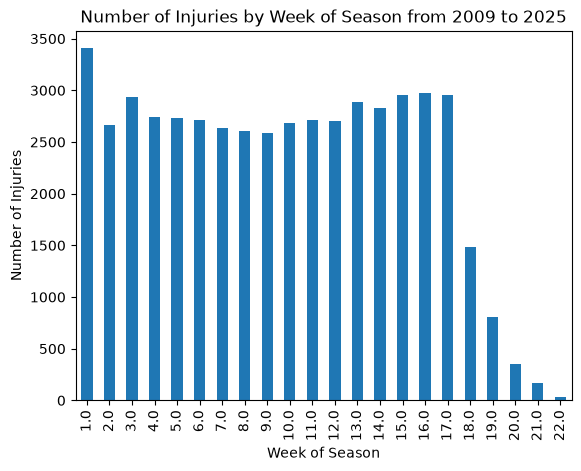

In [59]:
plt.figure()
injuries_spells_with_schedule_info.groupby('injury_onset_week')['clean_injury'].count().plot(kind='bar')
plt.title('Number of Injuries by Week of Season from 2009 to 2025')
plt.xlabel('Week of Season')
plt.ylabel('Number of Injuries')
plt.show()

In [60]:
# have some injuries grown or lost prevalence over the years?

df_trends = injuries_spells_with_schedule_info.copy()
df_trends["season"] = df_trends["season"].astype(int)

In [61]:
# Get total injuries per season to normalize rates
total_injuries_per_season = df_trends.groupby("season").size()

# Get count of each injury type per season
injury_season_counts = (
    df_trends.groupby(["season", "clean_injury"]).size().unstack(fill_value=0)
)

# Convert raw counts to Percentage of Total Injuries for that season (%)
injury_season_pct = (
    injury_season_counts.div(total_injuries_per_season, axis=0) * 100
)

In [62]:
# Plot the overall top 10 most frequent injuries
top_injuries = df_trends["clean_injury"].value_counts().head(10).index.tolist()
trend_subset = injury_season_pct[top_injuries]

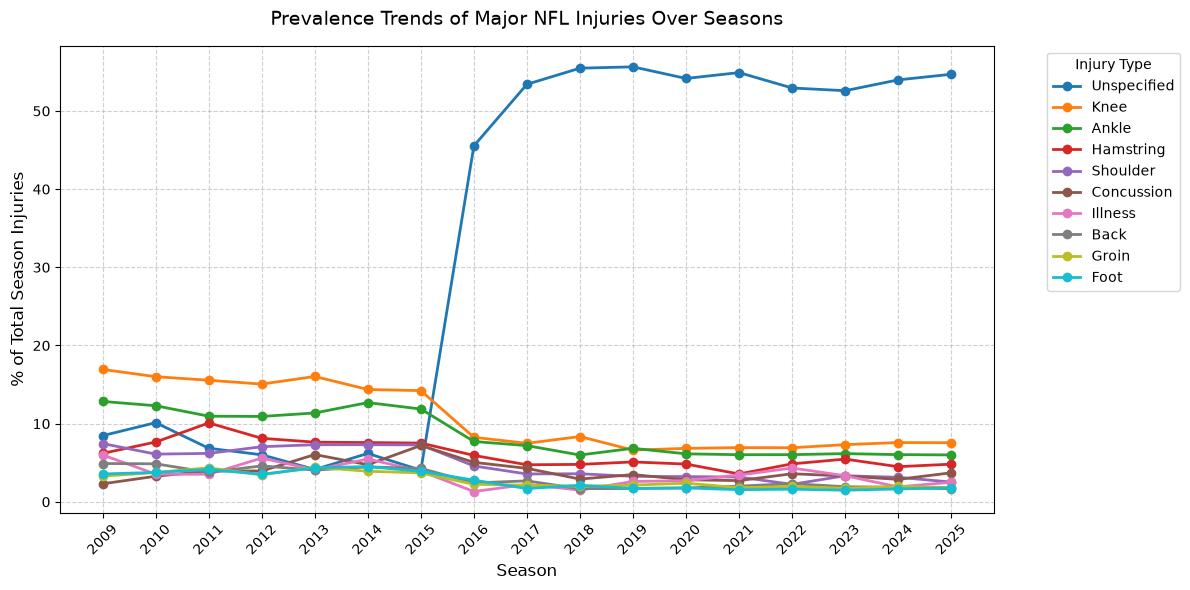

In [63]:
plt.figure(figsize=(12, 6))

for injury in top_injuries:
    plt.plot(
        trend_subset.index,
        trend_subset[injury],
        marker="o",
        linewidth=2,
        label=injury,
    )

plt.title(
    "Prevalence Trends of Major NFL Injuries Over Seasons", fontsize=14, pad=15
)
plt.xlabel("Season", fontsize=12)
plt.ylabel("% of Total Season Injuries", fontsize=12)
plt.xticks(
    ticks=trend_subset.index,
    labels=[str(s) for s in trend_subset.index],
    rotation=45,
)
plt.legend(title="Injury Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

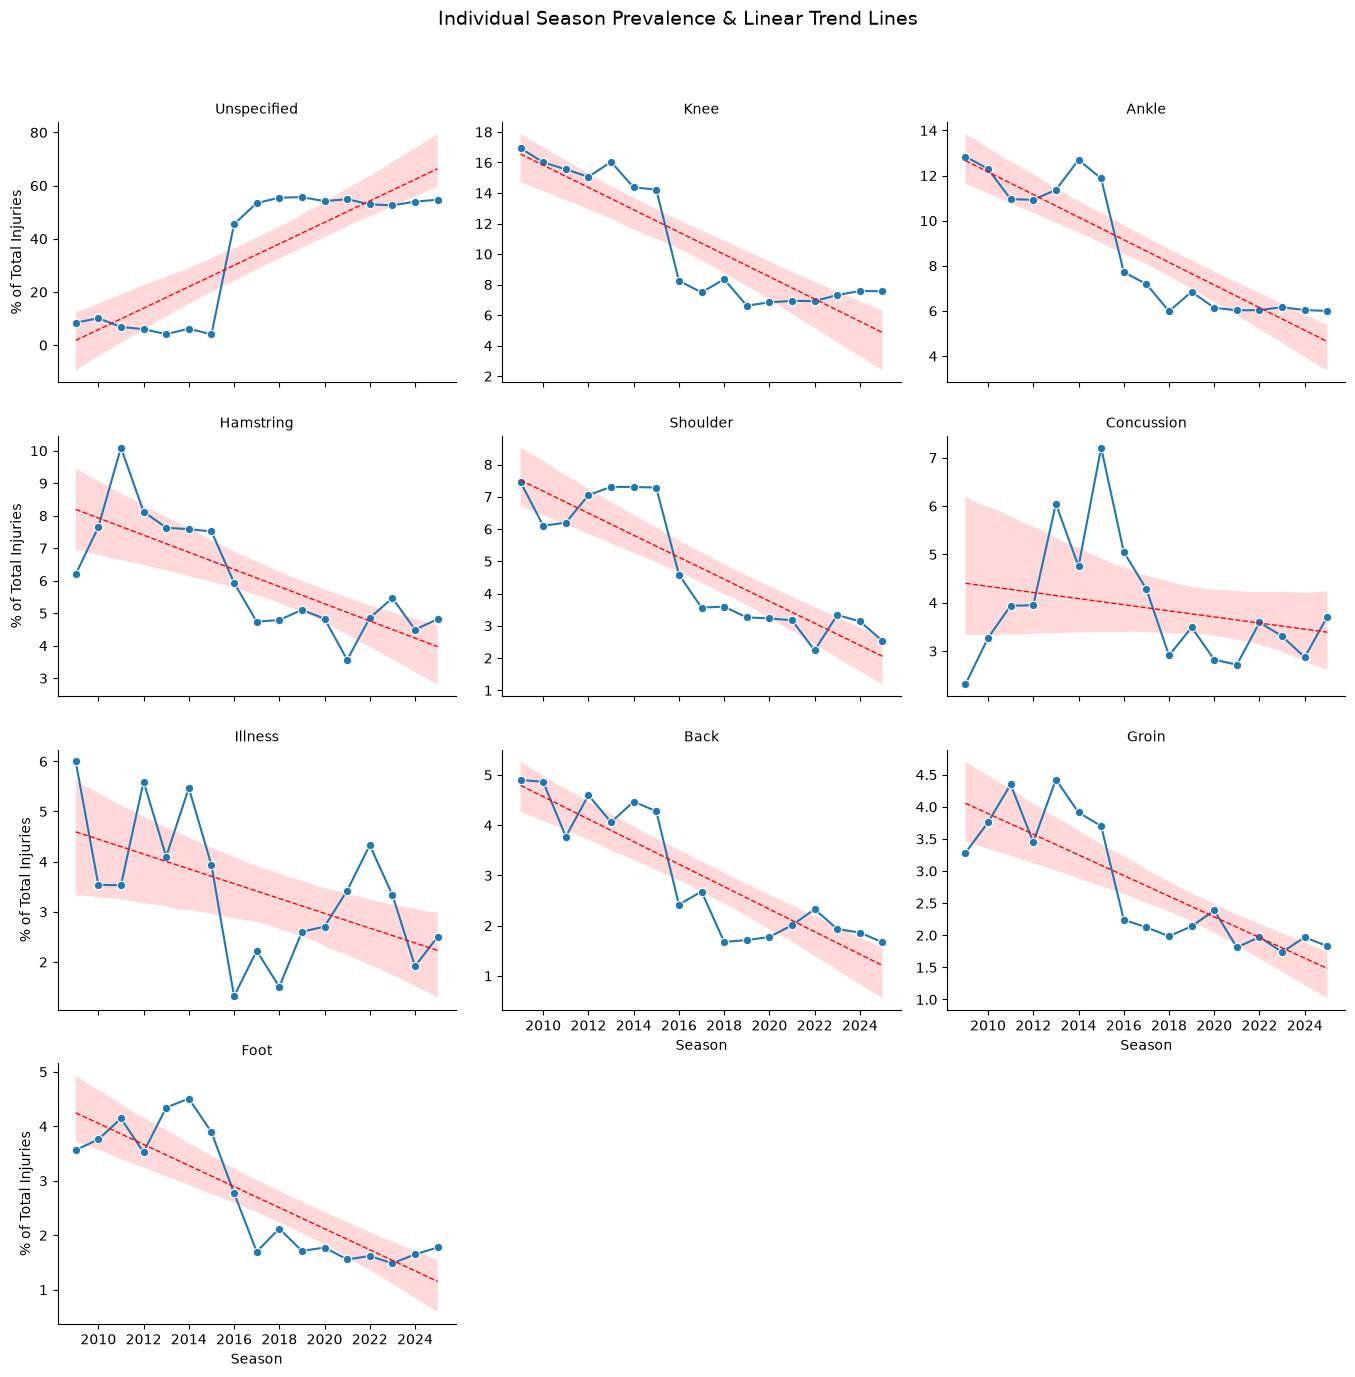

In [ ]:
# Reshape data to long format for Seaborn FacetGrid
long_pct = (
    trend_subset.reset_index().melt(
        id_vars="season", var_name="injury", value_name="pct"
    )
)

g = sns.FacetGrid(
    long_pct, col="injury", col_wrap=3, height=3.5, aspect=1.3, sharey=False
)
g.map(sns.lineplot, "season", "pct", marker="o", color="tab:blue")
g.map(sns.regplot, "season", "pct", scatter=False, color="red", line_kws={"linestyle": "--", "linewidth": 1}) # Adds trend line

g.set_axis_labels("Season", "% of Total Injuries")
g.set_titles(col_template="{col_name}")
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(
    "Individual Season Prevalence & Linear Trend Lines", fontsize=14
)

plt.show()